<a href="https://colab.research.google.com/github/israakadhem0-coder/Drug-discovery_ML/blob/main/bioactivity_prediction_app.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **QSAR Model Building of NRF2 **



# Read in data

In [1]:
import pandas as pd

In [7]:
df = pd.read_csv('/content/NRF2_Keap1_06_bioactivity_data_3class_pIC50_pubchem_fp.csv')

In [9]:
X = df.drop(['pIC50'], axis=1)
X

,PubchemFP0,PubchemFP1,PubchemFP2,PubchemFP3,PubchemFP4,PubchemFP5,PubchemFP6,PubchemFP7,PubchemFP8,PubchemFP9,...,PubchemFP871,PubchemFP872,PubchemFP873,PubchemFP874,PubchemFP875,PubchemFP876,PubchemFP877,PubchemFP878,PubchemFP879,PubchemFP880
0,1,1,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1,1,1,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
2,1,1,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
3,1,1,1,1,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
4,1,1,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
259,1,1,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
260,1,1,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
261,1,1,1,1,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
262,1,1,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0


In [11]:
Y = df.iloc[:,-1]
Y

,pIC50
0,3.928118
1,7.481486
2,7.698970
3,3.602060
4,7.356547
...,...
259,7.619789
260,8.113509
261,7.508638
262,5.000000


# Remove low variance features

In [12]:
from sklearn.feature_selection import VarianceThreshold

def remove_low_variance(input_data, threshold=0.1):
    selection = VarianceThreshold(threshold)
    selection.fit(input_data)
    return input_data[input_data.columns[selection.get_support(indices=True)]]

X = remove_low_variance(X, threshold=0.1)
X

,PubchemFP3,PubchemFP13,PubchemFP16,PubchemFP17,PubchemFP21,PubchemFP22,PubchemFP23,PubchemFP33,PubchemFP34,PubchemFP143,...,PubchemFP783,PubchemFP791,PubchemFP797,PubchemFP798,PubchemFP800,PubchemFP812,PubchemFP818,PubchemFP820,PubchemFP821,PubchemFP825
0,0,0,0,0,0,0,1,1,1,0,...,0,0,1,0,0,0,0,1,1,0
1,0,1,1,1,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,1,0,0,1,1,0,...,1,1,0,0,1,0,1,0,1,0
3,1,1,0,0,1,0,0,1,1,0,...,1,1,0,0,1,0,1,0,1,0
4,0,0,1,0,1,0,0,1,1,0,...,1,1,0,0,1,0,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
259,0,0,0,0,1,0,0,1,1,0,...,1,1,0,0,1,0,1,0,1,0
260,0,0,0,0,1,0,0,1,1,0,...,1,1,0,0,1,0,1,0,1,0
261,1,1,1,0,1,1,0,1,0,1,...,0,0,0,0,0,0,0,0,0,0
262,0,0,1,0,0,0,0,0,0,1,...,0,0,0,1,0,0,0,0,1,0


In [13]:
X.to_csv('descriptor_list.csv', index = False)

In [14]:
# In the app, use the following to get this same descriptor list
# of 218 variables from the initial set of 881 variables
# Xlist = list(pd.read_csv('descriptor_list.csv').columns)
# X[Xlist]

# Random Forest Regression Model

In [15]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [16]:
model = RandomForestRegressor(n_estimators=500, random_state=42)
model.fit(X, Y)
r2 = model.score(X, Y)
r2

0.877299293738986

## Model Prediction

In [17]:
Y_pred = model.predict(X)
Y_pred

array([4.276025  , 6.60416791, 7.43001585, 4.82558956, 7.20758631,
       6.10834402, 7.03835188, 6.52333656, 4.11888972, 3.29982336,
       6.49368437, 6.3359237 , 6.70847712, 7.21167985, 7.21167985,
       7.80655582, 7.34544756, 7.06118384, 6.14598167, 5.99728327,
       5.93467597, 7.50103539, 6.76364604, 6.41272143, 6.77246379,
       6.49775568, 6.69389445, 6.62180275, 6.67531707, 7.43001585,
       5.12943975, 4.77304648, 6.14598167, 7.21167985, 7.50103539,
       7.50103539, 7.59727354, 7.21167985, 7.21167985, 5.04101762,
       4.74502346, 6.42715923, 4.74502346, 6.42715923, 5.32686891,
       5.32686891, 5.22315319, 5.22315319, 5.22315319, 4.96199914,
       5.9334142 , 5.21196614, 6.01240315, 4.34234324, 4.87449798,
       4.42576576, 4.58279883, 4.58279883, 4.54331814, 4.46109296,
       4.46109296, 4.46109296, 4.38669852, 4.38168513, 4.31790413,
       4.31790413, 7.21167985, 7.08674446, 7.75236988, 3.36537649,
       3.82582486, 4.11888972, 4.11888972, 3.91098777, 4.32385

## Model Performance

In [18]:
print('Mean squared error (MSE): %.2f'
      % mean_squared_error(Y, Y_pred))
print('Coefficient of determination (R^2): %.2f'
      % r2_score(Y, Y_pred))

Mean squared error (MSE): 0.28
Coefficient of determination (R^2): 0.88


# Data Visualization (Experimental vs Predicted pIC50 for Training Data)

In [19]:
import matplotlib.pyplot as plt
import numpy as np

Text(0.5, 0, 'Experimental pIC50')

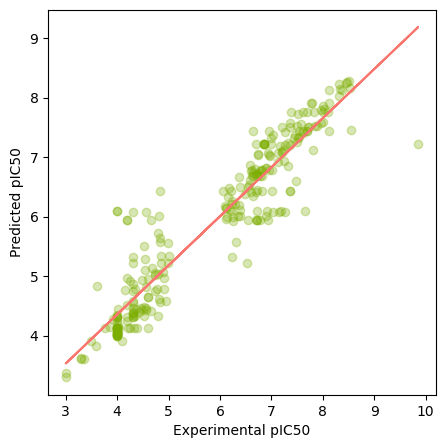

In [20]:
plt.figure(figsize=(5,5))
plt.scatter(x=Y, y=Y_pred, c="#7CAE00", alpha=0.3)

# Add trendline
# https://stackoverflow.com/questions/26447191/how-to-add-trendline-in-python-matplotlib-dot-scatter-graphs
z = np.polyfit(Y, Y_pred, 1)
p = np.poly1d(z)

plt.plot(Y,p(Y),"#F8766D")
plt.ylabel('Predicted pIC50')
plt.xlabel('Experimental pIC50')

# Save Model as Pickle Object

In [21]:
import pickle

In [22]:
pickle.dump(model, open('NRF2_Keap1_model.pkl', 'wb'))